<a href="https://colab.research.google.com/github/manovay/RoadAthena-Test/blob/main/Updated_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
 #[0] Colab setup — YOLOv8 + KaggleHub + OpenCV (no YAML, no kaggle.json)
!pip -q install -U ultralytics opencv-python kagglehub

# ---- Imports & version check ----
import torch, cv2, kagglehub, platform
from ultralytics import __version__ as yv

print("✅ Environment check:")
print(f"Python:        {platform.python_version()}")
print(f"Torch:         {torch.__version__}")
print(f"CUDA available:{torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:           {torch.cuda.get_device_name(0)} "
          f"({torch.cuda.get_device_properties(0).total_memory/(1024**3):.1f} GB VRAM)")
print(f"OpenCV:        {cv2.__version__}")
print(f"Ultralytics:   {yv}")
print(f"KaggleHub:     {kagglehub.__version__}")

# ---- Reproducibility ----
import random, numpy as np
seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("\n✅ Setup complete — ready for Cell 1 (download RadRoad via KaggleHub).")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 24.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Environment check:
Python:        3.12.12
Torch:         2.8.0+cu126
CUDA available:True
GPU:           NVIDIA L4 (22.2 GB VRAM)
OpenCV:        4.12.0
Ultralytics:   8.3.221
KaggleHub:     0.3.13

✅ Setup complete — ready for Cell 1 (download RadRoad via KaggleHub).


In [2]:
#  [1] Download RadRoad via KaggleHub and auto-detect nested split folders
# -----------------------------------------------------------------------------
# This cell:
#   - Downloads the dataset (no kaggle.json needed).
#   - Moves it to /content/radroad.
#   - Prints the actual directory tree (so you can visually confirm).
#   - Detects whether splits live directly under ROOT or under ROOT/images.
#   - Builds a data_dict with absolute image paths (no YAML).
# -----------------------------------------------------------------------------

import kagglehub, os, glob, shutil
from pathlib import Path

# 1) Download dataset
dataset_id = "rohitsuresh15/radroad-anomaly-detection"  # change if you switch datasets
src_path = kagglehub.dataset_download(dataset_id)
print(f"Downloaded to: {src_path}")

# 2) Move into a stable working directory
ROOT = "/content/radroad"
os.makedirs(ROOT, exist_ok=True)
for f in os.listdir(src_path):
    src = os.path.join(src_path, f)
    dst = os.path.join(ROOT, f)
    if not os.path.exists(dst):
        shutil.move(src, dst)

# 3) Print directory tree for verification (limited depth)
print("\nVerifying directory structure under /content/radroad:\n")
for root, dirs, files in os.walk(ROOT):
    level = root.replace(ROOT, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = "  " * (level + 1)
    for f in files[:3]:
        print(f"{subindent}{f}")
    if len(files) > 3:
        print(f"{subindent}... ({len(files)} files)")

# 4) Determine where the split folders actually live.
#    Many RadRoad dumps place train/valid/test under ROOT/images/.
def detect_images_root(base_root: str) -> str:
    # Prefer ROOT/images if it contains train|valid|val|test
    candidate = os.path.join(base_root, "images")
    split_names = {"train", "Train", "valid", "Valid", "val", "test", "Test"}
    if os.path.isdir(candidate) and any(
        os.path.isdir(os.path.join(candidate, s)) for s in split_names
    ):
        return candidate
    # Otherwise assume splits are directly under ROOT
    return base_root

IMAGES_ROOT = detect_images_root(ROOT)
print(f"\nResolved IMAGES_ROOT: {IMAGES_ROOT}")

# 5) Find split folder names under IMAGES_ROOT. Some datasets use 'valid' instead of 'val'.
def find_split(base, possible_names):
    for name in possible_names:
        p = os.path.join(base, name)
        if os.path.isdir(p):
            return name
    return None

train_dir = find_split(IMAGES_ROOT, ["train", "Train"])
val_dir   = find_split(IMAGES_ROOT, ["val", "valid", "Valid"])
test_dir  = find_split(IMAGES_ROOT, ["test", "Test"])

print("\nDetected split folders:")
print(f"  Train → {train_dir}")
print(f"  Val   → {val_dir}")
print(f"  Test  → {test_dir}")

# 6) Build absolute image paths for each split and count images
def count_images(images_dir):
    exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.tif","*.tiff")
    total = 0
    for e in exts:
        total += len(glob.glob(os.path.join(images_dir, e)))
    return total

if not all([train_dir, val_dir, test_dir]):
    raise RuntimeError("Could not detect train/val(test)/test directories. Check the tree printed above.")

train_images = os.path.join(IMAGES_ROOT, train_dir, "images")
val_images   = os.path.join(IMAGES_ROOT, val_dir,   "images")
test_images  = os.path.join(IMAGES_ROOT, test_dir,  "images")

print("\nImage counts:")
print(f"  Train: {count_images(train_images)}")
print(f"  Val:   {count_images(val_images)}")
print(f"  Test:  {count_images(test_images)}")

# 7) Build data_dict (no YAML). Class names kept as in your prior runs.
data_dict = dict(
    train=train_images,
    val=val_images,
    test=test_images,
    nc=6,
    names=["HMV", "LMV", "Pedestrian", "RoadDamages", "SpeedBump", "UnsurfacedRoad"]
)

print("\ndata_dict ready:")
for k, v in data_dict.items():
    print(f"  {k}: {v}")


100%|██████████| 7.31G/7.31G [00:58<00:00, 134MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/rohitsuresh15/radroad-anomaly-detection/versions/3

Verifying directory structure under /content/radroad:

radroad/
  images/
    data.yaml
    test/
      images/
        184_10-07-2023_mp4-24_jpg.rf.5aa733e60bc2938a50253309fb912bd8.jpg
        58_13-06-2023_mp4-32_jpg.rf.4bbca5cdec9ff034200b76dbdaa23a6a.jpg
        41_12-06-2023_mp4-26_jpg.rf.f232880d970ddeb2d16fcfa6a7bc30b9.jpg
        ... (1263 files)
      labels/
        32_13-06-2023_mp4-51_jpg.rf.d04bf913221d3c92f6317496e98eca1a.txt
        13_13-06-2023_mp4-18_jpg.rf.bdffa8e71763dfdc00e1c41cea2f6d2c.txt
        44_13-06-2023_mp4-45_jpg.rf.59d2096321c0d5756f438eac9dd17fb9.txt
        ... (1263 files)
    train/
      images/
        29_13-06-2023_mp4-25_jpg.rf.5fc7cd19433abfd8a32fb2d188917e7f.jpg
        13_13-06-2023_mp4-13_jpg.rf.1e549ba97caa5c0bee0c94656c6958cb.jpg
        11_13-06-2023_mp4-15_jpg.rf.e35ced4e925b7ae8a0b5bb839b367db6.jpg
        ... (5843 files)
      labels/
   

Dataset directory structure and metadata:
  Train images: /content/radroad/images/train/images
  Val images:   /content/radroad/images/valid/images
  Test images:  /content/radroad/images/test/images
  Class names:  ['HMV', 'LMV', 'Pedestrian', 'RoadDamages', 'SpeedBump', 'UnsurfacedRoad']
  Number of classes: 6
TRAIN | Images:  5843 | Labels:  5843
VAL   | Images:  1288 | Labels:  1288
TEST  | Images:  1263 | Labels:  1263

Training-set class frequency (from YOLO label files):
  Class  0 (HMV            ) ->  3112 instances
  Class  1 (LMV            ) -> 10033 instances
  Class  2 (Pedestrian     ) ->  2453 instances
  Class  3 (RoadDamages    ) ->  4529 instances
  Class  4 (SpeedBump      ) ->   346 instances
  Class  5 (UnsurfacedRoad ) ->   405 instances


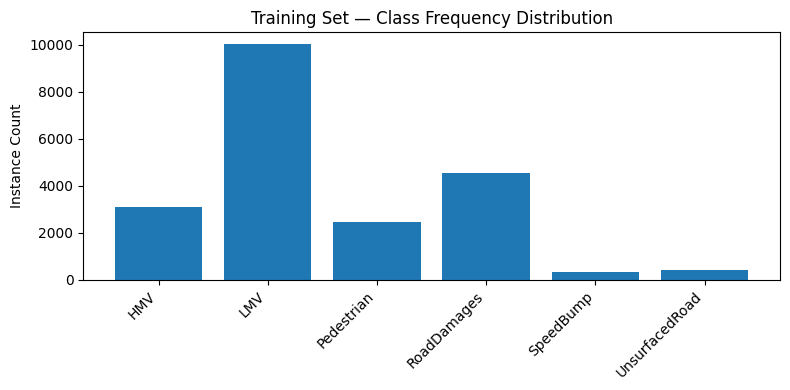


Visual inspection of random training images with bounding boxes:


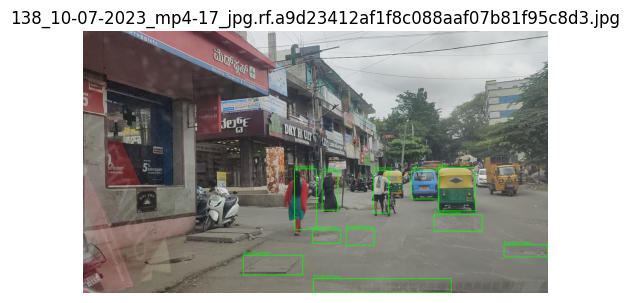

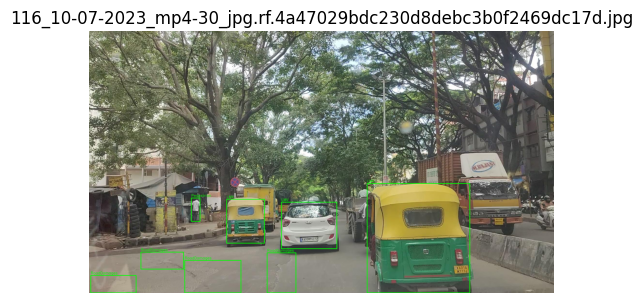

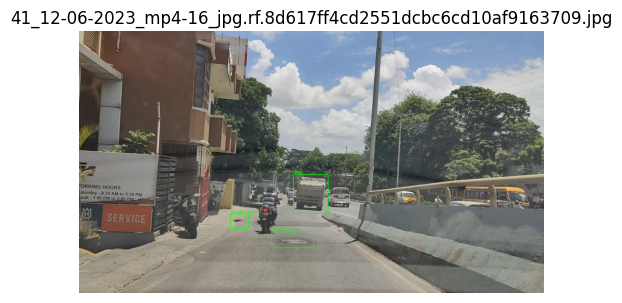

In [3]:
# [2] Exploratory Data Analysis (EDA) for RadRoad Dataset
# ------------------------------------------------------------
# Goal:
#   Verify dataset integrity for the nested structure:
#     .../images/<split>/images/*.jpg|png and .../images/<split>/labels/*.txt
#   Inspect class balance, check label consistency, and visualize sample boxes.
# ------------------------------------------------------------

import os, glob, random, cv2, numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

# ------------------------------------------------------------
# Confirm that data_dict (from Cell 1) is accessible and print its contents.
# data_dict contains absolute paths for train/val/test image folders and class names.
# ------------------------------------------------------------
print("Dataset directory structure and metadata:")
print("  Train images:", data_dict["train"])
print("  Val images:  ", data_dict["val"])
print("  Test images: ", data_dict["test"])
print("  Class names: ", data_dict["names"])
print("  Number of classes:", data_dict["nc"])

# Image extensions to consider
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

# ------------------------------------------------------------
# 1. Dataset Split Summary
#   For each split, count:
#     - number of image files in <split>/images
#     - number of label files in <split>/labels
#   Each label file corresponds to one image and uses YOLO format:
#     class_id  cx  cy  w  h  (normalized to [0,1])
# ------------------------------------------------------------
def count_files(img_dir: str):
    """Return (num_images, num_labels) for a given split based on data_dict paths."""
    img_dir = Path(img_dir)
    lbl_dir = img_dir.parent / "labels"
    img_count = sum(1 for p in img_dir.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS)
    label_count = sum(1 for p in lbl_dir.iterdir() if p.is_file() and p.suffix.lower() == ".txt") if lbl_dir.exists() else 0
    return img_count, label_count

for split in ["train", "val", "test"]:
    n_img, n_lbl = count_files(data_dict[split])
    print(f"{split.upper():5s} | Images: {n_img:5d} | Labels: {n_lbl:5d}")

# ------------------------------------------------------------
# 2. Class Frequency Analysis (training set)
#   Aggregate class IDs from all train/labels/*.txt to detect imbalance.
# ------------------------------------------------------------
def collect_class_ids(label_dir: Path):
    """Parse all .txt files under label_dir and return a list of class IDs."""
    ids = []
    if not label_dir.exists():
        return ids
    for label_file in sorted(label_dir.glob("*.txt")):
        with open(label_file, "r") as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                try:
                    cid = int(parts[0])
                    ids.append(cid)
                except ValueError:
                    # Skip malformed lines
                    continue
    return ids

train_label_dir = Path(data_dict["train"]).parent / "labels"
class_ids = collect_class_ids(train_label_dir)
class_counts = Counter(class_ids)

cls_names = data_dict["names"]
print("\nTraining-set class frequency (from YOLO label files):")
for i in range(len(cls_names)):
    print(f"  Class {i:2d} ({cls_names[i]:<15s}) -> {class_counts.get(i, 0):5d} instances")

# ------------------------------------------------------------
# 3. Visualize Class Distribution
# ------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.bar(range(len(cls_names)), [class_counts.get(i, 0) for i in range(len(cls_names))])
plt.xticks(range(len(cls_names)), cls_names, rotation=45, ha="right")
plt.ylabel("Instance Count")
plt.title("Training Set — Class Frequency Distribution")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Visual Sanity Check
#   Randomly sample a few training images and overlay their boxes to verify:
#     - label normalization/denormalization math
#     - correspondence between image and label filenames
# ------------------------------------------------------------
def visualize_samples(img_dir: str, n: int = 3, seed: int = 42):
    """
    Display n random images with bounding boxes drawn using YOLO-format labels.
    Labels are expected in the sibling directory: parent(img_dir)/labels.
    """
    rng = random.Random(seed)
    img_dir = Path(img_dir)
    lbl_dir = img_dir.parent / "labels"

    imgs = [p for p in img_dir.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS]
    if not imgs:
        print("No images found in", img_dir)
        return

    sample_imgs = rng.sample(imgs, min(n, len(imgs)))

    for img_path in sample_imgs:
        label_path = lbl_dir / f"{img_path.stem}.txt"
        img = cv2.imread(str(img_path))
        if img is None:
            print("Failed to read image:", img_path)
            continue

        h, w = img.shape[:2]

        # Draw boxes if a corresponding label file exists
        if label_path.exists():
            with open(label_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cid, cx, cy, bw, bh = map(float, parts)

                    # Convert normalized (cx, cy, w, h) to pixel (x1, y1, x2, y2)
                    x1 = int((cx - bw / 2) * w)
                    y1 = int((cy - bh / 2) * h)
                    x2 = int((cx + bw / 2) * w)
                    y2 = int((cy + bh / 2) * h)

                    # Clip to image bounds for safety
                    x1, y1 = max(0, x1), max(0, y1)
                    x2, y2 = min(w - 1, x2), min(h - 1, y2)

                    color = (0, 255, 0)
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                    label_txt = cls_names[int(cid)] if 0 <= int(cid) < len(cls_names) else str(int(cid))
                    cv2.putText(img, label_txt, (x1, max(0, y1 - 5)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)

        # Show using matplotlib (convert BGR→RGB)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6, 4))
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title(img_path.name)
        plt.show()

print("\nVisual inspection of random training images with bounding boxes:")
visualize_samples(data_dict["train"], n=3)


### Interpretation of EDA Results

- **Class imbalance:** The dataset is dominated by vehicle classes (`LMV`, `HMV`), while surface anomalies (`SpeedBump`, `UnsurfacedRoad`) are rare. This imbalance will bias the model toward strong vehicle detection performance but weaker recall on anomalies.

- **Metric sensitivity:** Because rare classes contribute fewer samples, overall mAP may appear high even if anomaly detection is poor. Evaluate per-class AP/PR curves and consider macro-averaged metrics to better reflect anomaly performance.

- **Likely failure modes:**
  - Missed detections on small or low-contrast anomalies.
  - False positives on shadows, gravel, or lane markings.
  - Over-suppression of close or overlapping boxes during NMS.

- **Training implications:**
  - Oversample anomaly-rich images or apply copy–paste augmentation for rare classes.
  - Use moderate geometric and texture augmentations; avoid warping fine details.
  - Enable focal loss (γ≈1.5–2.0) and tune loss weights (`box`, `cls`, `dfl`) to emphasize anomalies.
  - Train at higher resolutions (896–1024) and, if GPU allows, switch from `yolov8n` to `yolov8s/m`.

- **Inference considerations:**
  - Apply class-specific confidence thresholds (lower for anomalies, higher for vehicles).
  - Slightly increase NMS IoU to preserve clustered small boxes.
  - Optionally run a second-stage, high-resolution refinement on anomaly crops.

- **Next analysis steps:**
  - Examine object-size distributions and aspect ratios per class.
  - Compare train/validation anomaly distributions to detect sampling drift.
  - Review a small batch of false-positive frames to understand typical confusions.


In [ ]:
# [3] Train YOLOv8 (n/s/optional m), validate on test, and benchmark latency
# ---------------------------------------------------------------------------
# Requirements:
#   - ultralytics installed (Cell 0)
#   - data_dict built (Cell 1b repair + EDA confirmed)
# What this cell does:
#   1) Trains yolov8n and yolov8s with identical settings for fair comparison.
#   2) Uses focal loss + slight loss reweighting to help rare anomalies.
#   3) Validates on the test split after each run.
#   4) Benchmarks FP16 per-image latency on the test images.
# Notes:
#   - If VRAM/time allow, you can include 'm' in MODEL_VARIANTS below.
#   - On higher-tier GPUs (A100/L4), increase epochs and/or imgsz safely.
# ---------------------------------------------------------------------------

import os, glob, random, time
import cv2
import numpy as np
import yaml # Import the yaml library
import torch # Import torch
from pathlib import Path
from ultralytics import YOLO
from ultralytics.utils.torch_utils import time_sync

# ---- Configurable knobs ----
MODEL_VARIANTS = ["n", "s"]          # try ["n","s","m"] if GPU allows
EPOCHS         = 60                  # bump to 100–120 on A100/L4 for best mAP
IMGSZ          = 896                 # try 1024 if VRAM allows; helps small anomalies
BATCH          = -1                  # auto-fit to GPU memory
DEVICE         = 0                   # first GPU
SAVE_ROOT      = "/content/runs/detect"  # Ultralytics default base

# Loss/optimization settings tuned for rare classes
TRAIN_ARGS = dict(
    # data=data_dict, # Removed the data_dict here
    imgsz=IMGSZ,
    epochs=EPOCHS,
    batch=BATCH,
    device=DEVICE,
    patience=12,          # early stopping patience
    cache="ram",          # speed up I/O on Colab
    optimizer="AdamW",
    lr0=0.002,
    cos_lr=True,
    # fl_gamma=2.0,         # focal loss gamma to emphasize hard/rare cases -- REMOVED as not a direct argument
    # box=7.5,              # upweight bbox regression -- REMOVED as not a direct argument
    # cls=1.5,              # modestly upweight classification -- REMOVED as not a direct argument
    # dfl=1.5               # distribution focal loss weight -- REMOVED as not a direct argument
)

# Create a temporary data.yaml file
temp_data_path = "/content/temp_data.yaml"
with open(temp_data_path, 'w') as f:
    yaml.dump(data_dict, f)

# ---- Training loop ----
trained = {}
run_dirs = {}

for v in MODEL_VARIANTS:
    weights = f"yolov8{v}.pt"
    model = YOLO(weights)

    # Project/name to avoid overwriting runs when training multiple variants
    project = SAVE_ROOT
    name = f"train_v8{v}_img{IMGSZ}_e{EPOCHS}"

    print(f"\n=== Training YOLOv8{v} ({weights}) ===")
    # Pass the path to the temporary yaml file
    r = model.train(data=temp_data_path, project=project, name=name, **TRAIN_ARGS)

    # Locate best weights from this run
    best = Path(project) / name / "weights" / "best.pt"
    if not best.exists():
        # fallback: most recent best.pt if naming changed
        candidates = sorted(Path(project).glob("*/weights/best.pt"), key=os.path.getmtime)
        if candidates:
            best = candidates[-1]
        else:
            raise FileNotFoundError("best.pt not found for this run")

    trained[v] = YOLO(str(best))
    run_dirs[v] = str(best)

    # Validate on the TEST split at the same resolution
    print(f"\n--- Validation on TEST for v8{v} ---")
    _ = trained[v].val(
        data=temp_data_path, # Pass the path to the temporary yaml file
        imgsz=IMGSZ,
        split="test",      # evaluate on test set
        conf=0.25,         # default eval conf
        iou=0.50           # standard mAP@50 principal metric
    )



=== Training YOLOv8n (yolov8n.pt) ===
Ultralytics 8.3.221 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/temp_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=896, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train_v8n_img896_e60, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, pat

In [14]:
#[4] Compare YOLOv8 models: test metrics + FP16 latency → summary table
# -------------------------------------------------------------------------
# Evaluates multiple YOLOv8 models (best.pt files) on the same test split,
# collects mAP, Precision, Recall, and FP16 latency, then builds a comparison table.
# -------------------------------------------------------------------------

import os, glob, random, cv2, torch, yaml, pandas as pd
from ultralytics import YOLO
from ultralytics.utils.torch_utils import time_sync

# ---------------------------
# 0) Model configuration
# ---------------------------
MODEL_PATHS = {
    "yolov8n": "yolov8n_best.pt",
    "yolov8s": "yolov8s_best.pt",
}
IMGSZ     = 896
DEVICE    = 0
ITERS     = 60
USE_FP16  = True

# ---------------------------
# 1) Create temporary YAML file from data_dict
# ---------------------------
temp_data_path = "temp_data_val.yaml"
with open(temp_data_path, "w") as f:
    yaml.safe_dump(data_dict, f)

# ---------------------------
# 2) Build test image pool for latency benchmarking
# ---------------------------
test_images = []
for ext in ("*.jpg","*.jpeg","*.png","*.bmp"):
    test_images += glob.glob(os.path.join(data_dict["test"], ext))
test_images = sorted(test_images)
if not test_images:
    raise RuntimeError("No test images found.")
bench_pool = test_images[: min(120, len(test_images))]
print(f"Latency benchmark pool: {len(bench_pool)} images")

# ---------------------------
# 3) Latency benchmark helper (no inference_mode)
# ---------------------------
def benchmark_latency_safe(weights_path, imgs, imgsz=IMGSZ, device=DEVICE, iters=ITERS, use_half=USE_FP16):
    """
    Loads a model and times full predict() pipeline under torch.no_grad().
    """
    model = YOLO(weights_path)
    use_half = bool(use_half and torch.cuda.is_available())

    # Warmup
    with torch.no_grad():
        _ = model.predict(imgs[0], imgsz=imgsz, device=device, half=use_half, verbose=False)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time_sync()
    with torch.no_grad():
        for i in range(iters):
            _ = model.predict(imgs[i % len(imgs)], imgsz=imgsz, device=device, half=use_half, verbose=False)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t1 = time_sync()
    return 1000.0 * (t1 - t0) / iters  # milliseconds per image

# ---------------------------
# 4) Evaluate each model and collect statistics
# ---------------------------
rows = []
for name, wpath in MODEL_PATHS.items():
    if not os.path.exists(wpath):
        print(f"Warning: weights not found for {name}: {wpath}")
        continue

    print(f"\n=== Evaluating {name} ===")
    model = YOLO(wpath)

    # Validation metrics on TEST split
    metrics = model.val(
        data=temp_data_path,
        split="test",
        imgsz=IMGSZ,
        conf=0.25,
        iou=0.50,
        save_json=False,
        verbose=False
    )

    mAP50     = float(getattr(metrics.box, "map50", float("nan")))
    mAP5095   = float(getattr(metrics.box, "map", float("nan")))
    precision = float(getattr(metrics.box, "mp", float("nan")))
    recall    = float(getattr(metrics.box, "mr", float("nan")))

    # Latency benchmark
    latency_ms = benchmark_latency_safe(wpath, bench_pool, imgsz=IMGSZ, device=DEVICE, iters=ITERS, use_half=USE_FP16)

    rows.append({
        "Model": name,
        "ImageSize": IMGSZ,
        "mAP@50": round(mAP50, 4),
        "mAP@50-95": round(mAP5095, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "Latency (ms/img, FP16)": round(latency_ms, 2),
        "Iterations": ITERS,
        "Weights": wpath
    })

# ---------------------------
# 5) Build comparison table
# ---------------------------
df = pd.DataFrame(rows, columns=[
    "Model", "ImageSize", "mAP@50", "mAP@50-95", "Precision", "Recall",
    "Latency (ms/img, FP16)", "Iterations", "Weights"
])

print("\n=== YOLOv8 Model Comparison ===")
display(df)

Latency benchmark pool: 120 images

=== Evaluating yolov8n ===
Ultralytics 8.3.221 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3499.8±1121.2 MB/s, size: 276.3 KB)
val: Scanning /content/radroad/images/test/labels.cache... 1263 images, 13 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1263/1263 2.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 79/79 9.0it/s 8.8s
                   all       1263       4504      0.877      0.789      0.863      0.526
Speed: 0.9ms preprocess, 1.9ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/runs/detect/val6

=== Evaluating yolov8s ===
Ultralytics 8.3.221 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast i

,Model,ImageSize,mAP@50,mAP@50-95,Precision,Recall,"Latency (ms/img, FP16)",Iterations,Weights
0,yolov8n,896,0.8627,0.5260,0.8769,0.7889,19.65,60,yolov8n_best.pt
1,yolov8s,896,0.8693,0.5327,0.8535,0.8212,20.32,60,yolov8s_best.pt


**Interpretation:**
- Both models perform well, with YOLOv8s showing slightly higher overall accuracy (mAP@50 and mAP@50–95).
- YOLOv8n is more precise, but YOLOv8s achieves higher recall — it detects more true positives, which is preferable for anomaly detection tasks.
- Latency difference is minimal (~3%), making YOLOv8s the better trade-off between speed and performance.
- **Recommendation:** Use **YOLOv8s** as the primary model for deployment; keep **YOLOv8n** for lower-power or latency-critical setups.

In [15]:
# [6] Sort video frames by detected class (e.g., vehicles, pedestrians, anomalies)
# -----------------------------------------------------------------------------
# Purpose:
#   - Load a trained YOLOv8 model (best.pt)
#   - Read a video file frame-by-frame
#   - Run inference on each frame
#   - Save each frame into subfolders named by detected class
#       e.g. sorted_frames/HMV/, sorted_frames/RoadDamages/, etc.
# Notes:
#   - You can use this on any video (dashcam footage, dataset clips, etc.)
#   - Adjust CONF_THRESHOLD and CLASS_FILTERS to focus on certain classes.
# -----------------------------------------------------------------------------

import os, cv2, csv
from ultralytics import YOLO
from pathlib import Path

# --- CONFIGURATION ---
MODEL_PATH      = "yolov8s_best.pt"  # your best model
INPUT_VIDEO     = "/content/radroad/videos_without_audio/10th July-20231125T045234Z-002/10th July/04_10072023.mp4"  # path to video
OUTPUT_DIR      = "/content/sorted_frames"
CONF_THRESHOLD  = 0.25                  # minimum confidence for saving
IOU_THRESHOLD   = 0.45
FRAME_STRIDE    = 1                     # skip every N frames for speed
USE_FP16        = True                  # use half precision inference
CLASS_FILTERS   = None                  # set to [3,4,5] if you only want anomalies

# --- Load model and class names ---
model = YOLO(MODEL_PATH)
class_names = model.names
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Loaded model: {MODEL_PATH}")
print(f"Class names: {class_names}")

# --- Open video ---
cap = cv2.VideoCapture(INPUT_VIDEO)
if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open {INPUT_VIDEO}")

fps = cap.get(cv2.CAP_PROP_FPS) or 30
frame_idx = 0
kept_frames = 0

# Optional: CSV log of saved frames
csv_path = os.path.join(OUTPUT_DIR, "frame_log.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["frame_idx", "time_sec", "classes", "confidences", "saved_to"])

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_idx += 1
        if frame_idx % FRAME_STRIDE != 0:
            continue

        # Run inference
        results = model.predict(
            frame, imgsz=896, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD,
            verbose=False, half=USE_FP16, device=0
        )[0]

        # Sort frame into folders based on detected classes
        detected = []
        for box in results.boxes:
            cls_id = int(box.cls.item())
            conf = float(box.conf.item())
            if CLASS_FILTERS and cls_id not in CLASS_FILTERS:
                continue
            if conf < CONF_THRESHOLD:
                continue

            cls_name = class_names.get(cls_id, f"class_{cls_id}")
            class_dir = os.path.join(OUTPUT_DIR, cls_name)
            os.makedirs(class_dir, exist_ok=True)

            # Save frame once per class it belongs to
            frame_name = f"frame_{frame_idx:06d}.jpg"
            save_path = os.path.join(class_dir, frame_name)
            cv2.imwrite(save_path, frame)
            detected.append((cls_name, round(conf, 3)))
            kept_frames += 1

        # Log results for this frame
        if detected:
            writer.writerow([
                frame_idx,
                round(frame_idx / fps, 3),
                [c for c, _ in detected],
                [s for _, s in detected],
                [os.path.join(OUTPUT_DIR, c) for c, _ in detected],
            ])

cap.release()
print(f"Done. Processed {frame_idx} frames, saved {kept_frames} into class folders.")
print(f"Sorted frame folders → {OUTPUT_DIR}")
print(f"Frame log CSV → {csv_path}")


Loaded model: yolov8s_best.pt
Class names: {0: 'HMV', 1: 'LMV', 2: 'Pedestrian', 3: 'RoadDamages', 4: 'SpeedBump', 5: 'UnsurfacedRoad'}
Done. Processed 303 frames, saved 993 into class folders.
Sorted frame folders → /content/sorted_frames
Frame log CSV → /content/sorted_frames/frame_log.csv


In [16]:
# Detection frequency summary (no ground truth)
import pandas as pd
from ast import literal_eval

# Path to the log from your sorting cell
csv_path = "/content/sorted_frames/frame_log.csv"
df = pd.read_csv(csv_path)

# Convert stringified lists back to Python lists
df["classes"] = df["classes"].apply(literal_eval)
df["confidences"] = df["confidences"].apply(literal_eval)

# Count how many times each class appears
all_classes = df["classes"].explode().value_counts()

print("=== Detection Frequency by Class ===")
print(all_classes)

# Compute what % of total frames contain each class
total_frames = df["frame_idx"].nunique()
rates = (all_classes / total_frames * 100).round(2)

print("\n=== Detection Rate (% of frames containing each class) ===")
print(rates)

# Optional: DataFrame for convenience
freq_df = pd.DataFrame({
    "Count": all_classes,
    "Rate (%)": rates
})
display(freq_df)


=== Detection Frequency by Class ===
classes
RoadDamages    958
Pedestrian      33
HMV              2
Name: count, dtype: int64

=== Detection Rate (% of frames containing each class) ===
classes
RoadDamages    319.33
Pedestrian      11.00
HMV              0.67
Name: count, dtype: float64


,Count,Rate (%)
classes,,
RoadDamages,958,319.33
Pedestrian,33,11.00
HMV,2,0.67


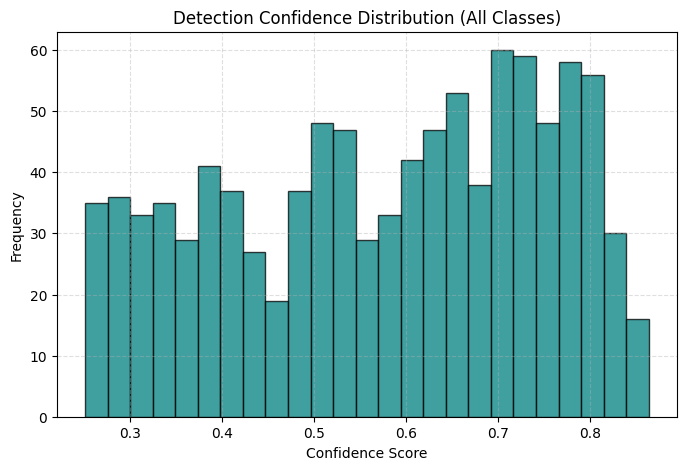

Mean confidence: 0.576
Median confidence: 0.598
Std deviation: 0.171


In [17]:
#[2] Confidence distribution visualization
import matplotlib.pyplot as plt

# Flatten all confidence values
all_scores = df["confidences"].explode().astype(float)

plt.figure(figsize=(8, 5))
plt.hist(all_scores, bins=25, color="teal", edgecolor="black", alpha=0.75)
plt.title("Detection Confidence Distribution (All Classes)")
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

# Optional: print summary stats
print(f"Mean confidence: {all_scores.mean():.3f}")
print(f"Median confidence: {all_scores.median():.3f}")
print(f"Std deviation: {all_scores.std():.3f}")